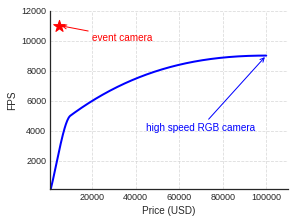

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import PchipInterpolator

# -----------------------------
# 1. 配置 Matplotlib 的全局字体大小
#    让其与 CVPR 正文字体(约 10pt)相当
# -----------------------------
matplotlib.rcParams.update({
    'font.size': 10,          # 基础字号
    'axes.labelsize': 10,     # 坐标轴标签字号
    'axes.titlesize': 10,     # 标题字号
    'xtick.labelsize': 9,     # x轴刻度文字
    'ytick.labelsize': 9,     # y轴刻度文字
    # 'font.family': 'Times New Roman',  # 如需特定字体，可在此指定
})

# 原始数据点（仅用于插值）
fps = [120, 5000, 9000]         # y 轴
price = [1000, 10000, 100000]   # x 轴

# 特殊红色星号点 (5k, 11k)
fps_star = 11000
price_star = 5000

# 使用 PCHIP 进行平滑插值
interpolator = PchipInterpolator(price, fps)
price_smooth = np.linspace(min(price), max(price), 500)
fps_smooth = interpolator(price_smooth)

# 2. 选用白底风格 + 创建画布
plt.style.use('seaborn-white')  # seaborn-white, 保证白色背景
fig, ax = plt.subplots(figsize=(4.2, 3.2))

# 强制画布和坐标区为白底（防止出现灰底或透明）
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# 3. 绘制平滑曲线
ax.plot(price_smooth, fps_smooth, color='blue', linewidth=2)

# 4. 绘制红色星号点
ax.scatter(price_star, fps_star, color='red', marker='*', s=150, zorder=10)

# 5. 带箭头标注 event camera
ax.annotate(
    'event camera',
    xy=(price_star, fps_star),    # 箭头指向 (5000, 11000)
    xytext=(20000, 10000),        # 文字位置，可根据实际情况微调
    arrowprops=dict(arrowstyle='->', color='red'),
    color='red',
    fontsize=10
)

# 6. 带箭头标注 high speed RGB camera
ax.annotate(
    'high speed RGB camera',
    xy=(price[-1], fps[-1]),      # 箭头指向 (100k, 9000)
    xytext=(70000, 4000),         # 文字位置，可根据实际情况微调
    arrowprops=dict(arrowstyle='->', color='blue'),
    color='blue',
    fontsize=10,
    ha='center'
)

# 7. 设置坐标轴标签（可视需要添加标题）
ax.set_xlabel('Price (USD)')
ax.set_ylabel('FPS')
# ax.set_title('FPS-Price trade-off', fontsize=10)

# 8. 去掉右、上边框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 9. 手动调节坐标范围，让图表更紧凑
ax.set_xlim(500, 110000)
ax.set_ylim(100, 12000)

# 10. 网格 + 紧凑布局
ax.grid(True, linestyle='--', alpha=0.7)
fig.tight_layout()

# 11. 保存并显示
#   facecolor='white' 确保输出图片也是白底
plt.savefig('FPSvsPrice.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
